<img src="https://cmse.msu.edu/_assets/images/about/image001.png"
     alt="CMSE Logo"
     align="right" 
     height="400" 
     width="400" />
# CMSE 801 - Day 22
## Using random numbers in computational models
### Application: diffusion of particles (i.e. a "random walk")
#### November 18, 2024

## General Course Announcements

* Homework 5 is out and is due **Friday, December 6, at 11:59pm**.
* Quiz 4 will be on **Wednesday of this week**.
    * This will be a `curve_fit` problem of some sort.
* Project Draft Presentations will also be during class on **Wednesday of this week**.
    * Details are on the [course website](https://cmse.msu.edu/cmse801) and in the Day 23 PCA.

## Questions/comments from Day 22 PCA

* Some issues came up with using the **seed** to control the random numbers and make the result reproducible.
* Some stuggles with `np.random.choice`.
* Questions about the "dice" problem.


## Generating random numbers from a distribution

N = 10: [ 0.66780991  4.51304154 -4.6947832   0.0722277   1.61735733 -4.21011977]
N = 100: [ 1.08336246 -4.40254056  3.10266251  2.50933373 -4.03367769 -2.03775101]
N = 1000: [-3.20896476 -0.13616607  3.50129496  4.63025073  0.85190705  0.37614793]


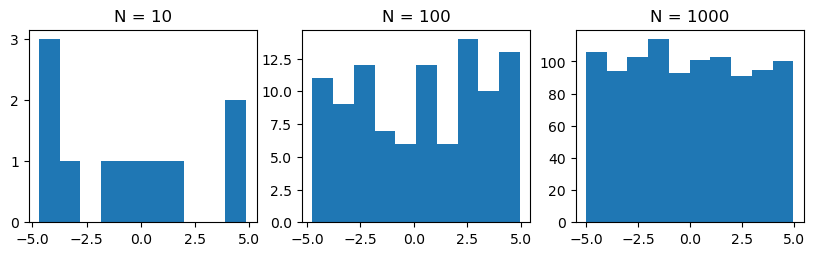

In [1]:
import numpy as np
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 3, figsize=(10,2.5))

for i,count in enumerate([10,100,1000]):
    vals = np.random.uniform(-5,5,size=count) #could also use "normal" or another other distribution
    print("N = %i:" %count,vals[:6])
    ax[i].hist(vals)
    ax[i].set_title('N = %i' %count)    

## But if I want reproducibility, I can specify a random _seed_

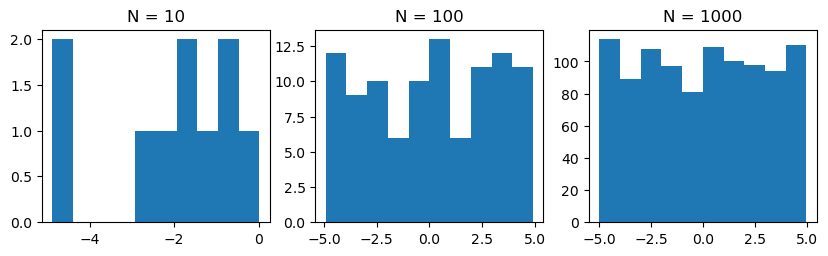

In [2]:
import numpy as np
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 3, figsize=(10,2.5))

np.random.seed(517) # Ensure that I always get the _same_ random numbers in the code that follows
for i,count in enumerate([10,100,1000]):
    vals = np.random.uniform(-5,5,size=count)
    ax[i].hist(vals)
    ax[i].set_title('N = %i' %count)

## I can use random numbers to simulate probabilities and make decisions in my code

* Random numbers can be useful for building models and finding best fit parameters. 
* Increases in computing power and reduction of computing costs has allow for the development of new tools and techniques aided by the generation of random numbers.
* When I introduce randomness, it can be harder to test my code or confirm reproducibility, **random seeds** help with this.

### Simulating probabilities

In [3]:
# Flip a coin N times, keep track of percent that come up "heads"
N = 100
count_heads = 0
for i in range(N):
    flip = np.random.randint(0, 2)
    if flip:
        count_heads += 1
print("Total flips: %i, Percent heads: %0.1f" %(N, ((count_heads/N)*100)))

Total flips: 100, Percent heads: 57.0


In [4]:
# "Rolling" a six-sided die
import random
for count in [100,1000,10_000]:
    ones = 0
    sixes = 0
    other = 0
    for i in range(count):
        roll = random.randint(1,6) #could use np.random as well, but arguments would need to change
        if roll == 1:
            ones += 1
        elif roll == 6:
            sixes += 1
        else:
            other += 1
    fractions = [ones/count,sixes/count,other/count]
    print("1/6 = ",1/6)
    print(fractions)

1/6 =  0.16666666666666666
[0.19, 0.18, 0.63]
1/6 =  0.16666666666666666
[0.145, 0.169, 0.686]
1/6 =  0.16666666666666666
[0.1617, 0.1666, 0.6717]


### Making decisions/choices

In [5]:
ope = ['a', 'b', 'c', 'd', 'e']

print("Choosing 1:",np.random.choice(ope))

print("Choosing 5 (non-unique):",np.random.choice(ope,size=5))

print("Choosing 2 (unique):",np.random.choice(ope,size=2,replace=False))

Choosing 1: a
Choosing 5 (non-unique): ['a' 'e' 'c' 'e' 'b']
Choosing 2 (unique): ['d' 'e']


## Goals for today
* Use random numbers to simulate a "random walk" to model diffusion of particles, also called "Brownian motion"
* Build the machine that can run one model
* Simulate several models for different numbers of random steps
* Analyze the average properties of these simulations to compare to an observed phenomenon

## For next time, Day 23 PCA:

* Work on your project, prepare a project draft presentation!